# Customer Segmentation & Churn Prediction

Customer churn is a major challenge for subscription-based businesses. 
Instead of applying the same retention strategy to all customers, companies can benefit from identifying distinct customer groups based on their behavior and characteristics.

This project applies unsupervised learning to segment customers and then trains separate machine learning models for each segment to predict churn.

The workflow includes:

1. Data preprocessing and feature encoding
2. Customer segmentation using clustering algorithms
3. Analysis of segment characteristics
4. Training Random Forest models for each segment
5. Model evaluation using multiple performance metrics
6. Extraction of business insights and recommendations

**Goal:**
Segment customers using clustering and build prediction models
for each segment to predict customer churn.

**Pipeline:**
Raw Data -> Preprocessing -> Processed Data -> Clustering -> Segment Profiles -> Segment Models -> Evaluation

## 1. IMPORT LIBRARIES

In [143]:
# Standard libraries
import os
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Machine learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

RANDOM_STATE = 42
OPTIMAL_CLUSTERS = 3  # determined using the elbow method

# Set visualization style
sns.set(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. DEFINE PROJECT PATHS

In [144]:
DATA_RAW_PATH = "../data/raw/customer_churn.csv"
DATA_PROCESSED_PATH = "../data/processed/segmentation_data.csv"
RESULTS_PATH = "../results/model_evaluation_results.csv"

print("Paths configured")

Paths configured


## 3. LOAD RAW DATASETS

In [145]:
def load_raw_data(path: str) -> pd.DataFrame:
    """
    Load dataset from given path.

    Parameters
    ----------
    path : str
        File path

    Returns
    -------
    pd.DataFrame
    """
    df = pd.read_csv(path)
    print(f"Dataset loaded: {df.shape}")
    return df


df_raw = load_raw_data(DATA_RAW_PATH)
df_raw.head()

Dataset loaded: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


## 4. DATA PREPROCESSING AND SAVE PROCESSED DATASET

Raw customer data often contains categorical variables and identifiers that cannot be directly used in machine learning models.

The preprocessing steps include:
• Removing non-informative identifiers (CustomerID)
• Encoding categorical variables into numeric format
• Preparing a cleaned dataset for clustering and modeling

The processed dataset is saved separately to ensure reproducibility of the pipeline.

In [146]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and transform dataset.

    Steps:
    - Drop ID column
    - Encode categorical variables
    - Handle missing values
    """

    df = df.copy()

    # Remove ID column
    if "CustomerID" in df.columns:
        df.drop(columns=["CustomerID"], inplace=True)

    # Identify categorical columns
    categorical_cols = df.select_dtypes(include="object").columns

    # Encode categorical features
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

    return df


df_processed = preprocess_data(df_raw)

df_processed.head()

,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,6,64,1540,1,1,0,1,0
1,21,113,1753,0,2,1,1,0
2,27,31,1455,2,1,0,1,0
3,53,29,7150,0,2,0,1,0
4,16,185,1023,1,2,0,1,0


In [147]:
os.makedirs("../data/processed", exist_ok=True)

df_processed.to_csv(DATA_PROCESSED_PATH, index=False)

print("Processed dataset saved successfully")

Processed dataset saved successfully


## 5. LOAD PROCESSED DATASET

In [148]:
df = pd.read_csv(DATA_PROCESSED_PATH)

print("Processed dataset loaded:", df.shape)

df.head()

Processed dataset loaded: (500, 8)


,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,6,64,1540,1,1,0,1,0
1,21,113,1753,0,2,1,1,0
2,27,31,1455,2,1,0,1,0
3,53,29,7150,0,2,0,1,0
4,16,185,1023,1,2,0,1,0


## 6. FEATURE SCALING

Clustering algorithms are sensitive to the scale of variables. 
Features such as monthly charges and tenure have different numeric ranges, which can bias clustering results.

StandardScaler is used to normalize the feature values so that each variable contributes equally to the clustering process.

In [149]:
def scale_features(df):

    X = df.drop("Churn", axis=1)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    return X, X_scaled


X, X_scaled = scale_features(df)

print("Features scaled successfully")

Features scaled successfully


## 7. DETERMINE OPTIMAL CLUSTERS (ELBOW METHOD)

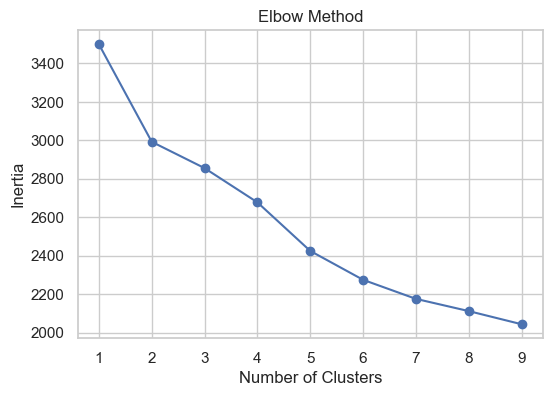

In [150]:
def plot_elbow_method(X_scaled):

    inertia = []

    for k in range(1, 10):

        model = KMeans(n_clusters=k, random_state=RANDOM_STATE)
        model.fit(X_scaled)

        inertia.append(model.inertia_)

    plt.figure(figsize=(6,4))
    plt.plot(range(1,10), inertia, marker="o")
    plt.title("Elbow Method")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.show()


plot_elbow_method(X_scaled)

The elbow plot suggests that the optimal number of clusters is 3.
Therefore, K-Means will be configured with n_clusters = 3 in the clustering step.

## 8. CLUSTERING ALGORITHM AND CLUSTER VISUALIZATION

Clustering algorithms group similar customers together based on behavioral patterns.

Three clustering algorithms are applied:
• K-Means
• Hierarchical Clustering
• DBSCAN

K-Means is used as the primary segmentation approach because it provides clear cluster assignments and works well for structured numerical datasets.

In [151]:
def apply_clustering(df, X_scaled):

    df = df.copy()

    # KMeans
    kmeans = KMeans(n_clusters=OPTIMAL_CLUSTERS, random_state=RANDOM_STATE)
    df["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

    # Hierarchical
    hierarchical = AgglomerativeClustering(n_clusters=OPTIMAL_CLUSTERS)
    df["Cluster_Hierarchical"] = hierarchical.fit_predict(X_scaled)

    # DBSCAN
    dbscan = DBSCAN(eps=0.8, min_samples=5)
    df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

    return df

df = apply_clustering(df, X_scaled)

df.head()

,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Cluster_KMeans,Cluster_Hierarchical,Cluster_DBSCAN
0,6,64,1540,1,1,0,1,0,1,0,-1
1,21,113,1753,0,2,1,1,0,1,2,-1
2,27,31,1455,2,1,0,1,0,1,0,-1
3,53,29,7150,0,2,0,1,0,1,0,-1
4,16,185,1023,1,2,0,1,0,1,0,-1


DBSCAN identified most customers as noise due to
dataset density characteristics. Therefore,
K-Means was selected as the primary segmentation method.

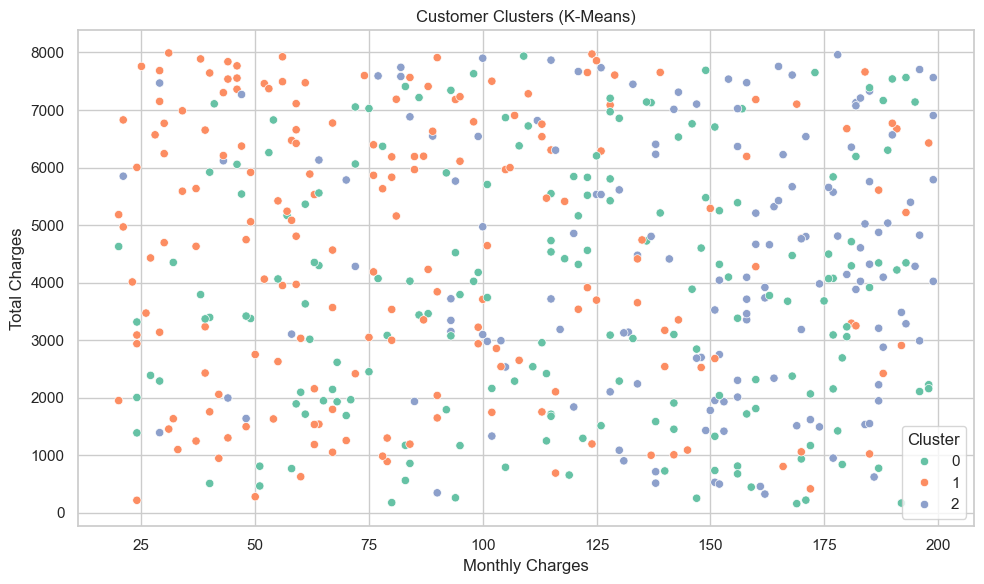

Cluster visualization saved to ../results/cluster_visualizations.png


In [153]:
# Cluster Visualization

def save_cluster_visualizations(df, output_path="../results/cluster_visualizations.png"):

    """
    Create cluster visualization plots and save them.
    """

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=df,
        x="MonthlyCharges",
        y="TotalCharges",
        hue="Cluster_KMeans",
        palette="Set2"
    )

    plt.title("Customer Clusters (K-Means)")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Total Charges")

    plt.legend(title="Cluster")

    plt.tight_layout()

    plt.savefig(output_path)

    plt.show()

    print(f"Cluster visualization saved to {output_path}")

save_cluster_visualizations(df)

# CLUSTER DISTRIBUTION ANALYSIS

Cluster Distribution
Cluster_KMeans
1    180
0    177
2    143
Name: count, dtype: int64


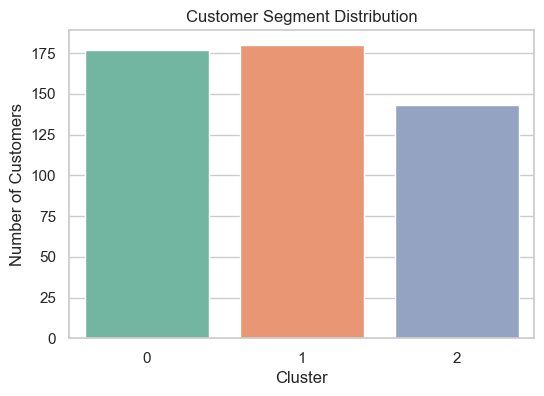

In [154]:
cluster_counts = df["Cluster_KMeans"].value_counts()

print("Cluster Distribution")
print(cluster_counts)

plt.figure(figsize=(6,4))

sns.countplot(
    x="Cluster_KMeans",
    data=df,
    palette="Set2"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

## 9. PCA-BASED CLUSTER VISUALIZATION

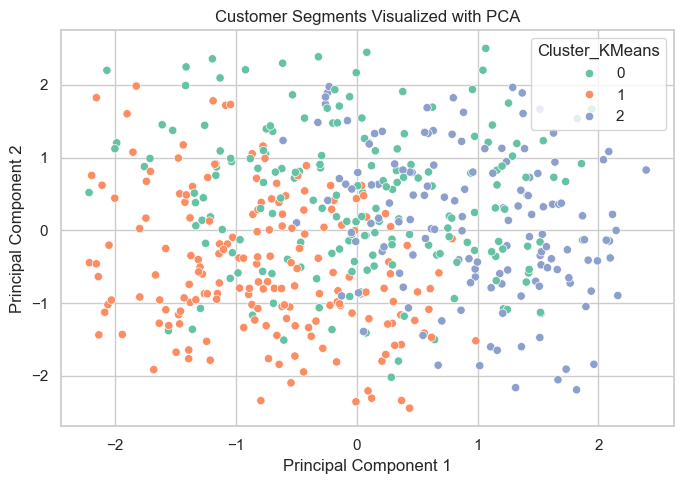

PCA visualization saved to ../results/pca_clusters.png


In [155]:
def visualize_clusters_pca(df, X_scaled, output_path="../results/pca_clusters.png"):
    """
    Reduce dataset to 2 dimensions using PCA
    and visualize clusters.
    """

    pca = PCA(n_components=2, random_state=RANDOM_STATE)

    pca_data = pca.fit_transform(X_scaled)

    df["PCA1"] = pca_data[:,0]
    df["PCA2"] = pca_data[:,1]

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df,
        x="PCA1",
        y="PCA2",
        hue="Cluster_KMeans",
        palette="Set2"
    )

    plt.title("Customer Segments Visualized with PCA")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.tight_layout()

    os.makedirs("../results", exist_ok=True)

    plt.savefig(output_path)

    plt.show()

    print(f"PCA visualization saved to {output_path}")


visualize_clusters_pca(df, X_scaled)

## 10. SEGMENT ANALYSIS

Customer segmentation helps businesses understand different groups of users.
Each segment may have different spending patterns, risk of churn, and service expectations.

By identifying these segments, companies can apply targeted marketing and retention strategies rather than a single generic approach.

In [156]:
def analyze_segments(df):

    profile = df.groupby("Cluster_KMeans").mean()

    print("Segment Profiles:")
    display(profile)


analyze_segments(df)

segment_summary = df.groupby("Cluster_KMeans").agg({
    "Tenure":"mean",
    "MonthlyCharges":"mean",
    "TotalCharges":"mean",
    "Churn":"mean"
})

segment_summary.rename(columns={
    "Tenure":"Avg_Tenure",
    "MonthlyCharges":"Avg_Monthly_Charges",
    "TotalCharges":"Avg_Total_Charges",
    "Churn":"Churn_Rate"
}, inplace=True)

segment_summary

Segment Profiles:


,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Cluster_Hierarchical,Cluster_DBSCAN,PCA1,PCA2
Cluster_KMeans,,,,,,,,,,,,
0,40.700565,117.920904,3762.627119,0.870056,0.197740,0.644068,0.446328,0.067797,1.146893,-0.971751,-0.016504,0.429100
1,33.222222,85.650000,4591.727778,0.911111,1.300000,0.200000,0.800000,0.111111,0.477778,-1.000000,-0.758746,-0.513411
2,35.538462,143.559441,4380.734266,1.090909,1.643357,0.650350,0.181818,0.146853,0.986014,-0.930070,0.975493,0.115127


,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Cluster_KMeans,,,,
0,40.700565,117.920904,3762.627119,0.067797
1,33.222222,85.650000,4591.727778,0.111111
2,35.538462,143.559441,4380.734266,0.146853


| Segment | Interpretation                   |
| ------- | -------------------------------- |
| 0       | Long-tenure high-value customers |
| 1       | Medium tenure moderate spending  |
| 2       | High monthly charge customers    |

## 11. TRAIN SEGMENT-SPECIFIC MODELS WITH HYPERPARAMETER TUNING

Instead of training a single model for the entire dataset, separate models are trained for each customer segment.

This approach improves predictive accuracy because:
• Different customer groups may have different churn drivers
• Segment-specific models can capture these patterns more effectively

Random Forest is used due to its strong performance and ability to capture nonlinear relationships.

In [157]:
# Each segment is modeled independently to capture
# different churn behavior patterns among customer groups.

def train_segment_models(df):

    results = []
    trained_models = {}

    segments = df["Cluster_KMeans"].unique()

    for seg in segments:

        print(f"\nTraining model for Segment {seg}")

        segment_df = df[df["Cluster_KMeans"] == seg]

        X = segment_df.drop(
            ["Churn","Cluster_KMeans","Cluster_Hierarchical","Cluster_DBSCAN"],
            axis=1
        )

        y = segment_df["Churn"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=RANDOM_STATE
        )

        # Hyperparameter tuning

        param_grid = {
            "n_estimators":[100,200],
            "max_depth":[5,10,None],
            "min_samples_split":[2,5]
        }

        grid = GridSearchCV(
            RandomForestClassifier(random_state=RANDOM_STATE),
            param_grid,
            cv=3,
            scoring="f1",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        # Save trained model
        os.makedirs("../models", exist_ok=True)

        model_path = f"../models/model_segment_{seg}.pkl"

        joblib.dump(best_model, model_path)

        print(f"Model saved to {model_path}")

        # store trained model
        trained_models[seg] = best_model

        # Predictions

        preds = best_model.predict(X_test)
        probs = best_model.predict_proba(X_test)[:,1]

        # Metrics

        metrics = {

            "Segment": seg,
            "Best_Params": grid.best_params_,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0),
            "ROC_AUC": roc_auc_score(y_test, probs)

        }

        results.append(metrics)

    return pd.DataFrame(results), trained_models, X.columns

results_df, trained_models, feature_names = train_segment_models(df)

results_df


Training model for Segment 1
Model saved to ../models/model_segment_1.pkl

Training model for Segment 0
Model saved to ../models/model_segment_0.pkl

Training model for Segment 2
Model saved to ../models/model_segment_2.pkl


,Segment,Best_Params,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.972222,1.0,0.75,0.857143,1.0
1,0,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",1.000000,1.0,1.00,1.000000,1.0
2,2,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",1.000000,1.0,1.00,1.000000,1.0


In [159]:
# Save model evaluation results to CSV

import os

def save_model_results(results_df, output_path="../results/model_evaluation_results.csv"):

    # ensure results directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # save file
    results_df.to_csv(output_path, index=False)

    print(f"Model evaluation results saved to: {output_path}")


# Save results
save_model_results(results_df)

Model evaluation results saved to: ../results/model_evaluation_results.csv


## 12. FEATURE IMPORTANCE ANALYSIS

Feature importance scores from the Random Forest models help identify the most influential variables affecting churn.

Understanding these drivers allows businesses to design targeted strategies to reduce churn and improve customer retention.


Feature Importance for Segment 1


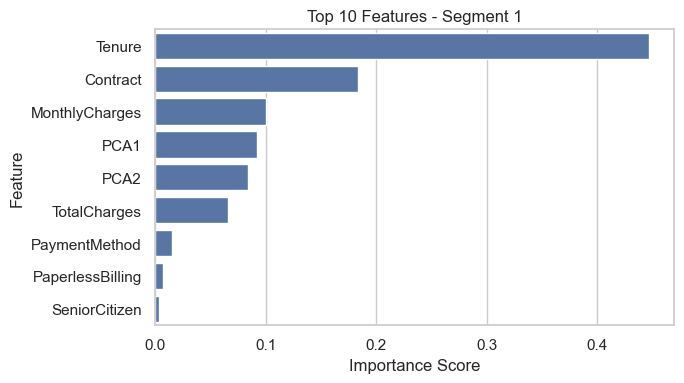

Saved: ../results/feature_importance_segment_1.png

Feature Importance for Segment 0


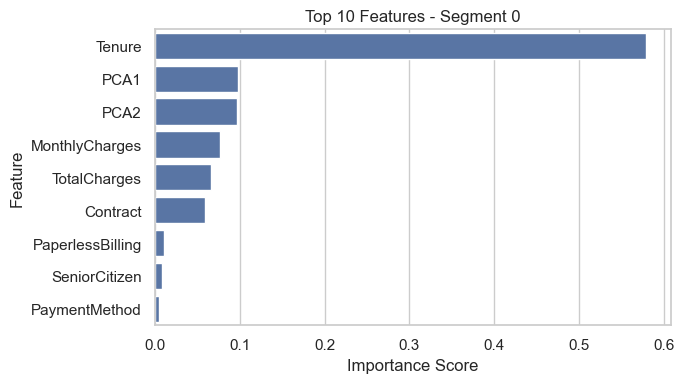

Saved: ../results/feature_importance_segment_0.png

Feature Importance for Segment 2


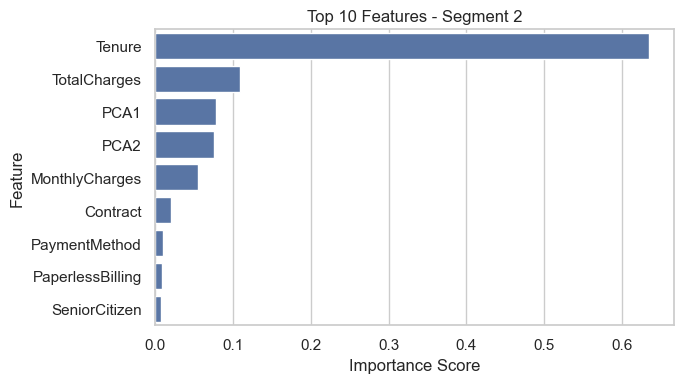

Saved: ../results/feature_importance_segment_2.png


In [160]:
def plot_feature_importance(trained_models, feature_names, top_n=10):

    """
    Plot feature importance for each trained segment model.

    Parameters
    ----------
    trained_models : dict
        Dictionary of trained models per segment

    feature_names : list
        List of feature names

    top_n : int
        Number of top features to display
    """

    os.makedirs("../results", exist_ok=True)
    
    for segment, model in trained_models.items():

        print(f"\nFeature Importance for Segment {segment}")

        importances = model.feature_importances_

        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        # Select top features
        importance_df = importance_df.head(top_n)

        plt.figure(figsize=(7,4))

        sns.barplot(
            data=importance_df,
            x="Importance",
            y="Feature"
        )

        plt.title(f"Top {top_n} Features - Segment {segment}")
        plt.xlabel("Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()

        file_path = f"../results/feature_importance_segment_{segment}.png"
        plt.savefig(file_path)
        
        plt.show()

        print(f"Saved: {file_path}")
        
plot_feature_importance(trained_models, feature_names)

In [161]:
# Save feature importance results

feature_importance_results = []

for segment, model in trained_models.items():

    importances = model.feature_importances_

    for feature, importance in zip(feature_names, importances):

        feature_importance_results.append({
            "Segment": segment,
            "Feature": feature,
            "Importance": importance
        })

importance_df = pd.DataFrame(feature_importance_results)

importance_df.sort_values(
    ["Segment","Importance"],
    ascending=[True,False],
    inplace=True
)

importance_df.to_csv("../results/feature_importance_results.csv", index=False)

print("Feature importance results saved")

Feature importance results saved


## 13. CONCLUSION

This project demonstrates how machine learning can be applied to identify customer segments and predict churn risk. Clustering algorithms revealed three distinct customer groups with different behavioral characteristics.

Segment-specific Random Forest models achieved strong predictive performance across all segments. Feature importance analysis showed that tenure, total charges, and monthly charges are the most influential variables affecting churn.

These insights can help organizations design targeted retention strategies and improve long-term customer value.

**Due to the relatively small dataset size, the model may exhibit optimistic performance metrics. Further validation on larger datasets would improve generalization confidence.**